# **To read dataset**

## Importing necessary libaries

In [1]:
import numpy as np
import struct
from array import array
from os.path  import join

## Defining class

In [2]:
class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())        
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img            
        
        return images, labels
            
    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test)

## Verify Reading Dataset via MnistDataloader class


In [4]:
%matplotlib inline
import random
import matplotlib.pyplot as plt

## Set file paths based on added MIST Datasets

In [13]:
from pathlib import Path

dataset_path = Path.cwd() / "dataset"

training_images_filepath = dataset_path / "train-images.idx3-ubyte"
training_labels_filepath = dataset_path / "train-labels.idx1-ubyte"
test_images_filepath = dataset_path / "t10k-images.idx3-ubyte"
test_labels_filepath = dataset_path / "t10k-labels.idx1-ubyte"

## Helper function to show a list of images with their relating titles


In [14]:
def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1    
    for x in zip(images, title_texts):        
        image = x[0]        
        title_text = x[1]
        plt.subplot(rows, cols, index)        
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);        
        index += 1

## Helper function to show a list of images with their relating titles


In [11]:
def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1    
    for x in zip(images, title_texts):        
        image = x[0]        
        title_text = x[1]
        plt.subplot(rows, cols, index)        
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);        
        index += 1

## Load MINST Datset

In [15]:
mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

## Show some random training and test images 


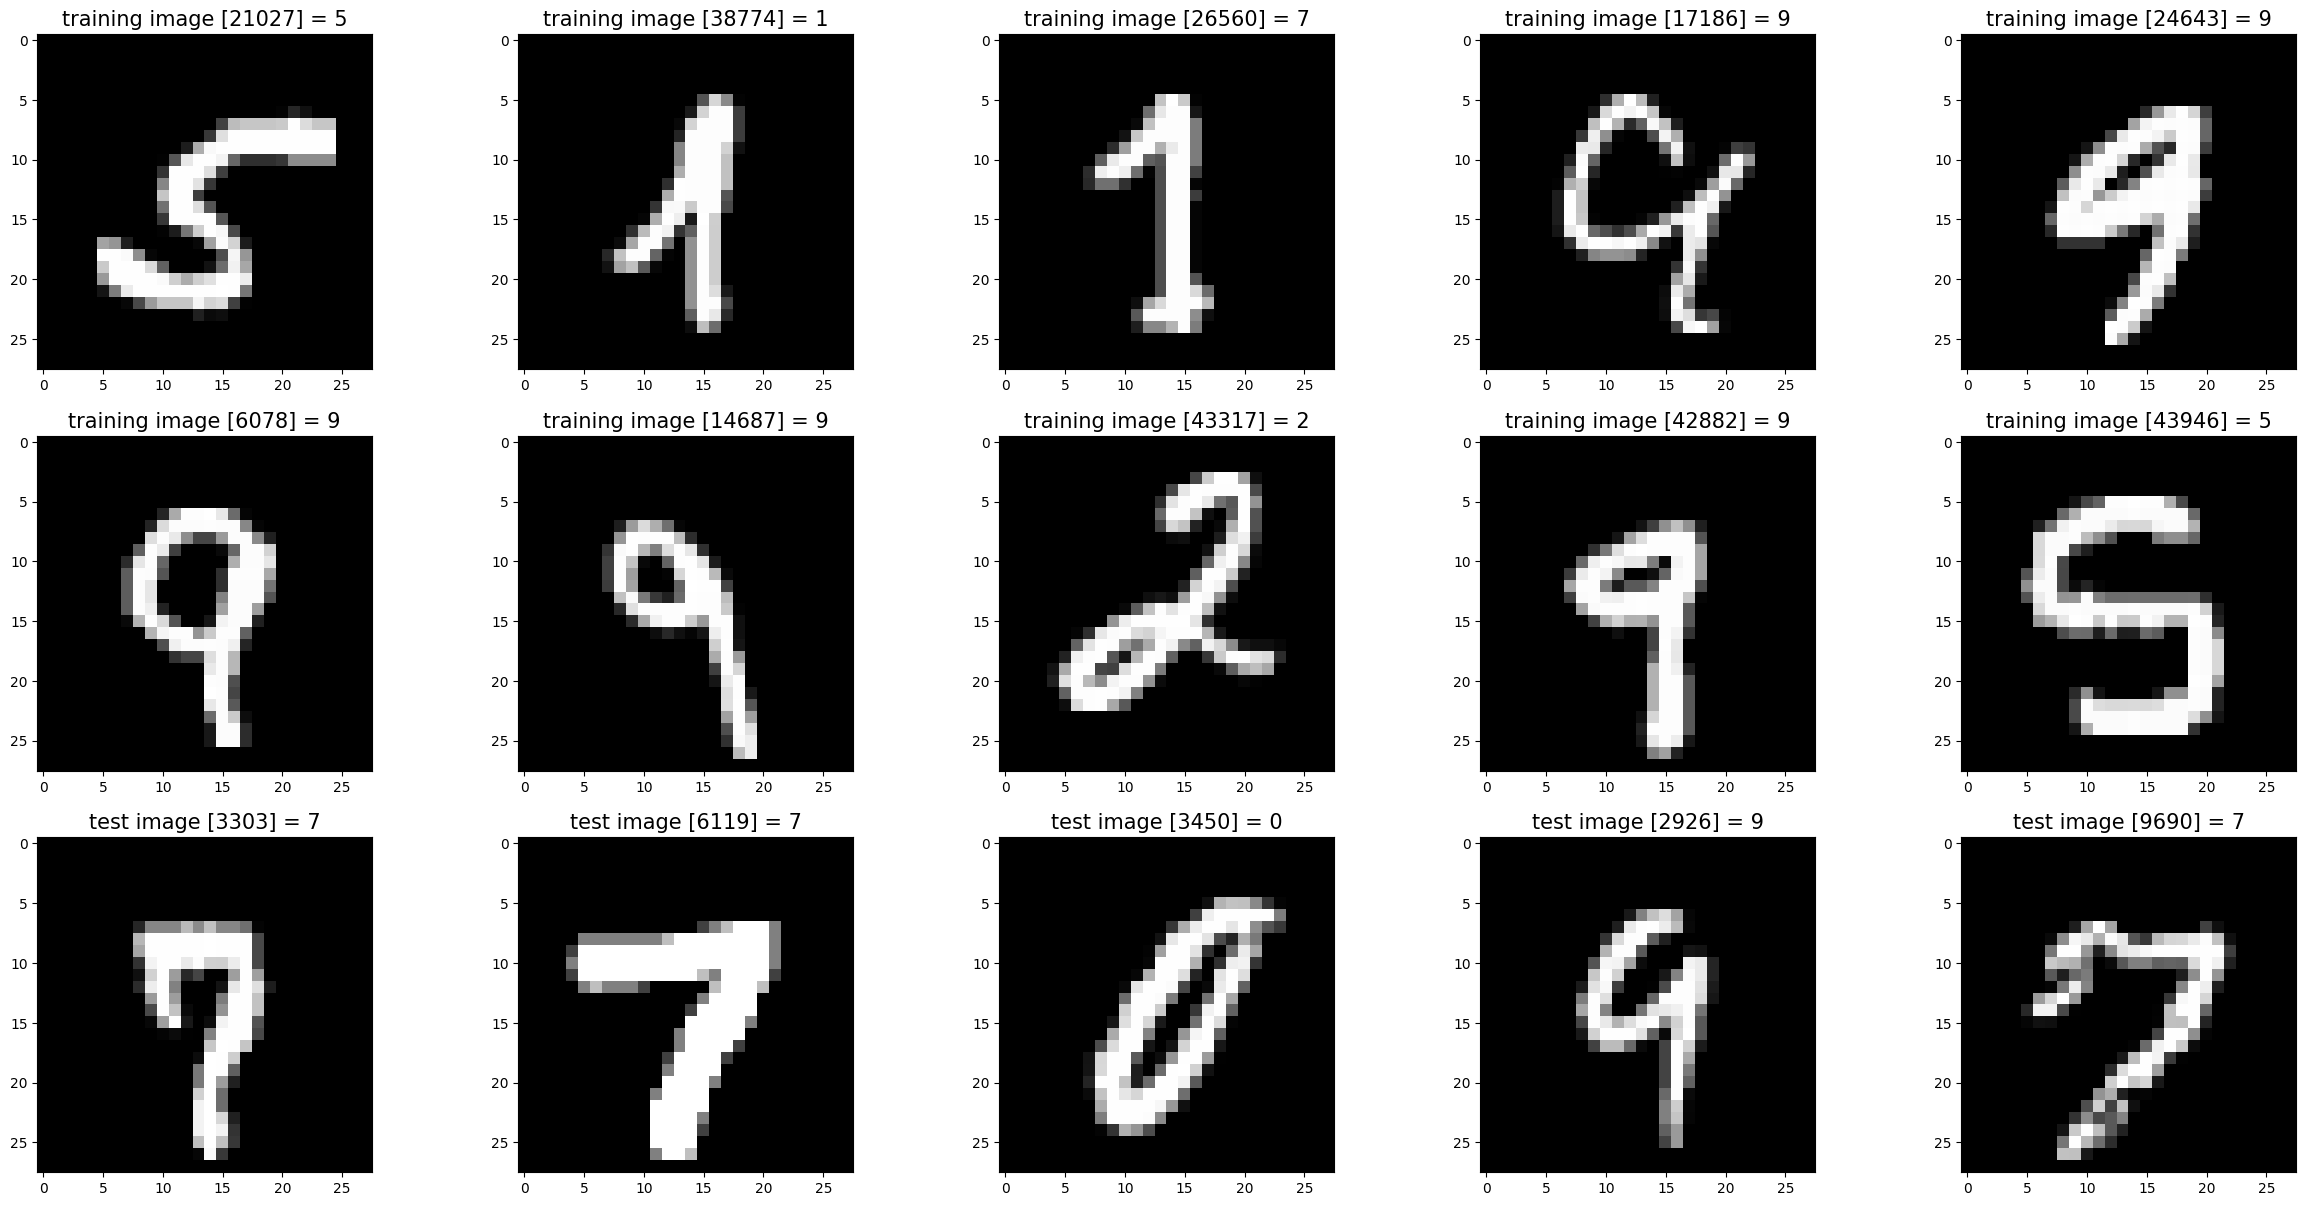

In [18]:
images_2_show = []
titles_2_show = []
for i in range(0, 10):
    r = random.randint(1, 60000)
    images_2_show.append(x_train[r])
    titles_2_show.append('training image [' + str(r) + '] = ' + str(y_train[r]))    

for i in range(0, 5):
    r = random.randint(1, 10000)
    images_2_show.append(x_test[r])        
    titles_2_show.append('test image [' + str(r) + '] = ' + str(y_test[r]))    

show_images(images_2_show, titles_2_show)

## Inspecting the actual data

In [20]:
x_train = np.asarray(x_train)
x_test = np.asarray(x_test)
y_train = np.asarray(y_train)
y_test = np.asarray(y_test)

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)

print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)

print("Pixel data type:", x_train.dtype)
print("Pixel range:", x_train.min(), "to", x_train.max())

Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)
Pixel data type: uint8
Pixel range: 0 to 255


## Flattening and normalizing the image

In [21]:
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)
x_train = x_train / 255.0
x_test = x_test / 255.0
print(x_train.shape)
print(x_test.shape)
print(x_train.min(), x_train.max())

(60000, 784)
(10000, 784)
0.0 1.0


## Training first model

In [23]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Make predictions

In [24]:
y_pred = model.predict(x_test)

In [30]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
wrong = np.where(y_pred != y_test)[0]

print("Total wrong:", len(wrong))
print("Accuracy:", 1 - len(wrong) / len(y_test))

Total wrong: 736
Accuracy: 0.9264


## Finding out why the model gets wrong

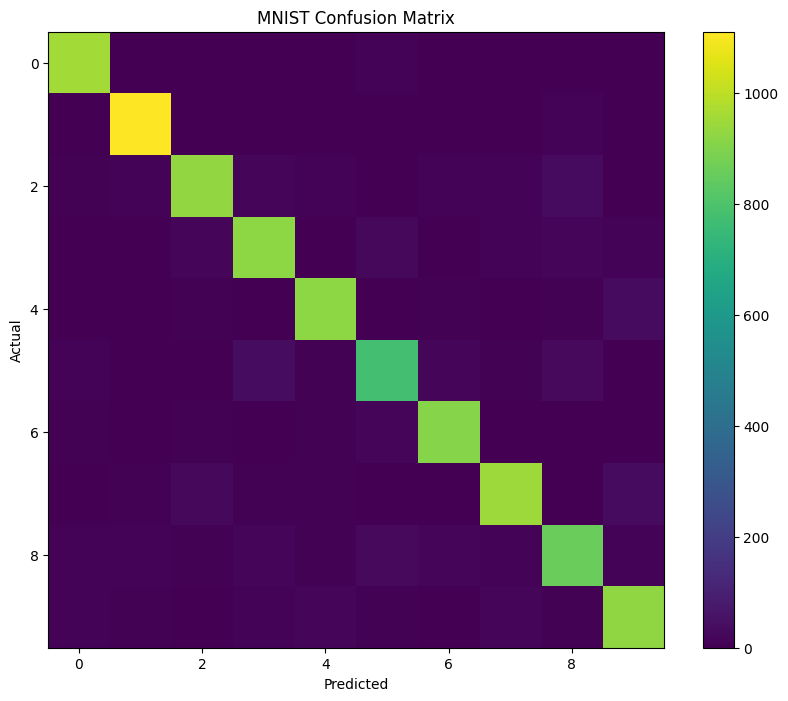

In [31]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MNIST Confusion Matrix")
plt.colorbar()
plt.show()

## Looking at where the model fails

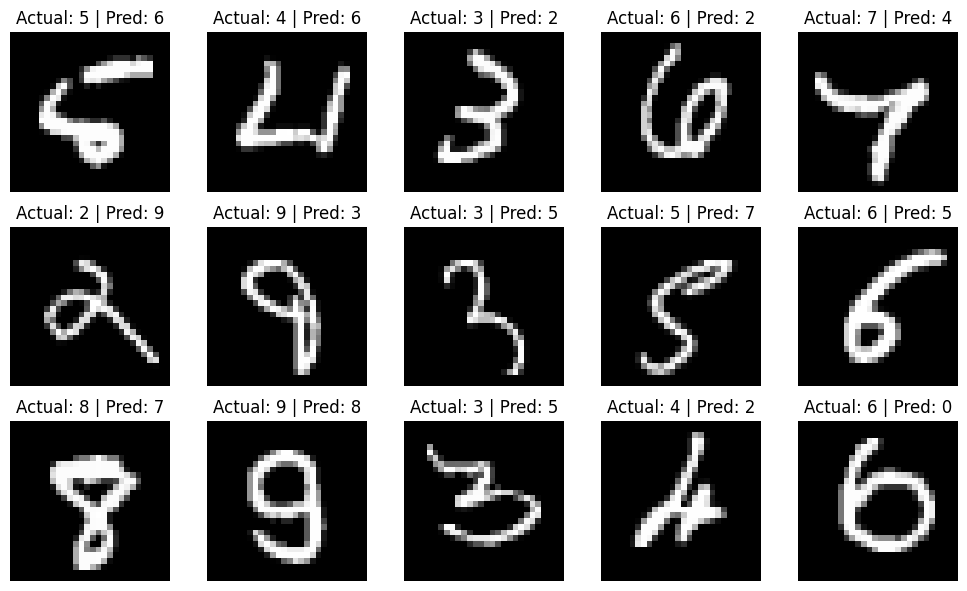

In [33]:
fig, axes = plt.subplots(3, 5, figsize=(10, 6))

for ax, i in zip(axes.ravel(), wrong[:15]):
    ax.imshow(x_test[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"Actual: {y_test[i]} | Pred: {y_pred[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Finding the most common mistake across all errors

In [35]:
from collections import Counter

mistakes = Counter(zip(y_test[wrong], y_pred[wrong]))

print(mistakes.most_common(10))

[((np.uint8(5), np.uint8(3)), 35), ((np.uint8(2), np.uint8(8)), 33), ((np.uint8(7), np.uint8(9)), 32), ((np.uint8(4), np.uint8(9)), 31), ((np.uint8(5), np.uint8(8)), 30), ((np.uint8(8), np.uint8(5)), 27), ((np.uint8(3), np.uint8(5)), 25), ((np.uint8(7), np.uint8(2)), 24), ((np.uint8(9), np.uint8(7)), 21), ((np.uint8(8), np.uint8(3)), 21)]


## Visualizing the worst mistakes

Number of 5 → 3 mistakes: 35


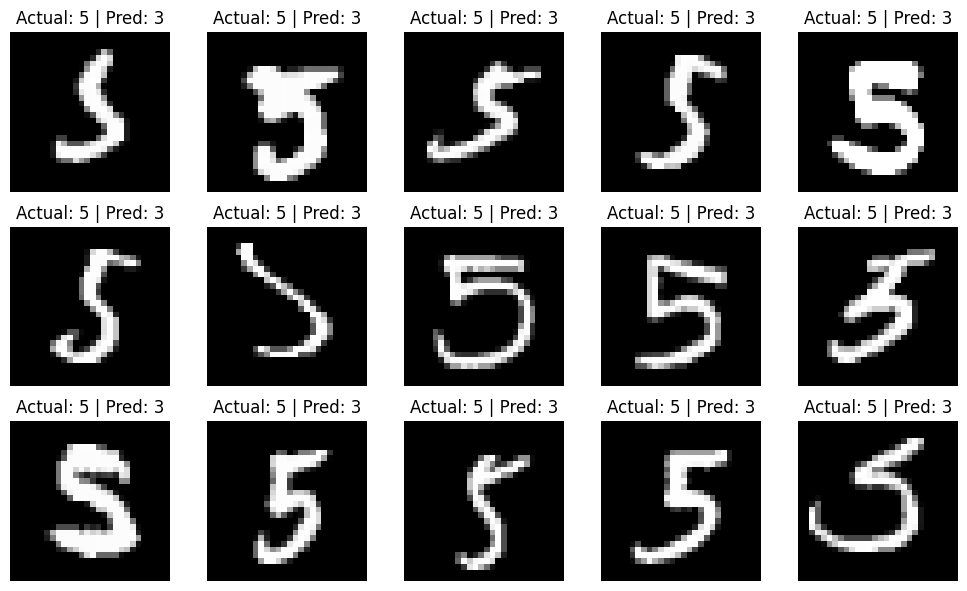

In [36]:
pair_indices = np.where((y_test == 5) & (y_pred == 3))[0]

print("Number of 5 → 3 mistakes:", len(pair_indices))

fig, axes = plt.subplots(3, 5, figsize=(10, 6))

for ax, i in zip(axes.ravel(), pair_indices[:15]):
    ax.imshow(x_test[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"Actual: {y_test[i]} | Pred: {y_pred[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Trying Random Forest Classifier

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(x_train, y_train)

rf_pred = rf_model.predict(x_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest accuracy:", rf_accuracy)

Random Forest accuracy: 0.9704


## Finding the Random Forest mistakes

In [38]:
rf_wrong = np.where(rf_pred != y_test)[0]

print("Random Forest wrong:", len(rf_wrong))

Random Forest wrong: 296


## Comparing the worst mistake pairs

In [39]:
rf_mistakes = Counter(zip(y_test[rf_wrong], rf_pred[rf_wrong]))

print(rf_mistakes.most_common(10))

[((np.uint8(7), np.uint8(2)), 20), ((np.uint8(4), np.uint8(9)), 16), ((np.uint8(9), np.uint8(3)), 12), ((np.uint8(9), np.uint8(4)), 12), ((np.uint8(7), np.uint8(9)), 10), ((np.uint8(5), np.uint8(3)), 9), ((np.uint8(3), np.uint8(7)), 9), ((np.uint8(3), np.uint8(5)), 9), ((np.uint8(3), np.uint8(2)), 9), ((np.uint8(2), np.uint8(7)), 8)]


## Visualizing

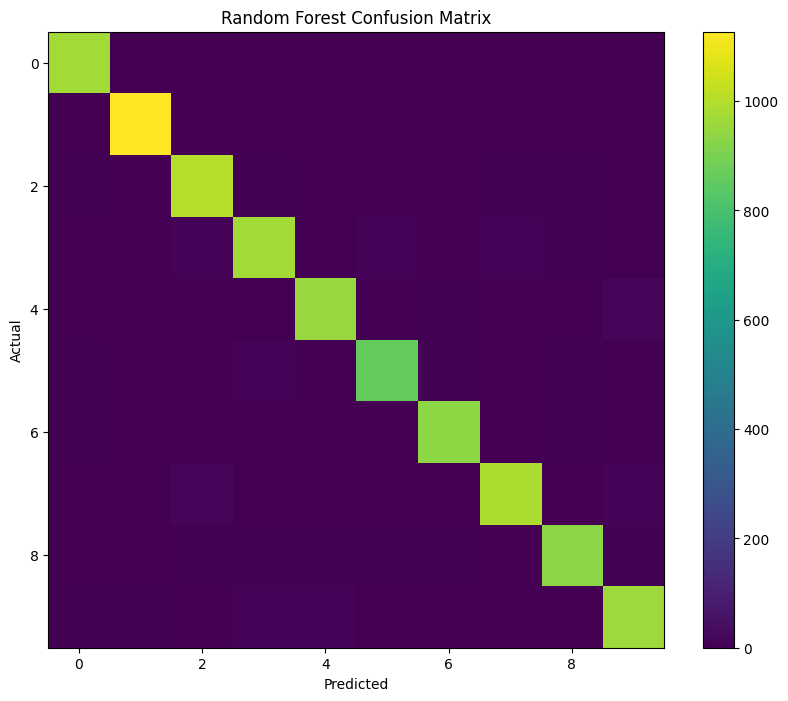

In [40]:
rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(10, 8))
plt.imshow(rf_cm)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.colorbar()
plt.show()

## Finding the largest possible mistake automatically

In [43]:
rf_cm_no_diag = rf_cm.copy()

np.fill_diagonal(rf_cm_no_diag, 0)

actual, predicted = np.unravel_index(
    np.argmax(rf_cm_no_diag),
    rf_cm_no_diag.shape
)

print("Most common mistake:", actual, "→", predicted)
print("Number of mistakes:", rf_cm_no_diag[actual, predicted])

Most common mistake: 7 → 2
Number of mistakes: 20


# Neural Network

## Checking version of TensorFlow

In [44]:
import tensorflow as tf

print(tf.__version__)

c:\Users\Aw Tha Da\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


2.20.0


In [46]:
import tensorflow as tf
import keras

nn_model = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

nn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## Train

In [47]:
nn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = nn_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9228 - loss: 0.2710 - val_accuracy: 0.9647 - val_loss: 0.1255
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9648 - loss: 0.1177 - val_accuracy: 0.9723 - val_loss: 0.0949
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9756 - loss: 0.0812 - val_accuracy: 0.9772 - val_loss: 0.0799
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9818 - loss: 0.0607 - val_accuracy: 0.9745 - val_loss: 0.0889
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9856 - loss: 0.0472 - val_accuracy: 0.9780 - val_loss: 0.0729
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9884 - loss: 0.0374 - val_accuracy: 0.9775 - val_loss: 0.0771
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9911 - loss: 0.0289 - val_accuracy: 0.9785 - val_loss: 0.0783
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9922 - loss: 0.0238 - 

## Test

In [48]:
test_loss, test_accuracy = nn_model.evaluate(x_test, y_test, verbose=0)

print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)

Test accuracy: 0.977400004863739
Test loss: 0.07911694049835205


## Investigating which neural network gets wrong

In [49]:
nn_pred = np.argmax(nn_model.predict(x_test, verbose=0), axis=1)

nn_wrong = np.where(nn_pred != y_test)[0]

print("Neural Network wrong:", len(nn_wrong))

Neural Network wrong: 226


In [50]:
nn_mistakes = Counter(zip(y_test[nn_wrong], nn_pred[nn_wrong]))

print(nn_mistakes.most_common(10))

[((np.uint8(8), np.int64(5)), 15), ((np.uint8(6), np.int64(5)), 12), ((np.uint8(3), np.int64(5)), 12), ((np.uint8(4), np.int64(9)), 11), ((np.uint8(5), np.int64(3)), 10), ((np.uint8(8), np.int64(3)), 7), ((np.uint8(9), np.int64(7)), 7), ((np.uint8(2), np.int64(7)), 6), ((np.uint8(7), np.int64(1)), 6), ((np.uint8(2), np.int64(8)), 6)]


# Time for CNN (Convolutional Neural Network)

For a CNN, we need the original 28×28 format. 

In [51]:
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

print(x_train_cnn.shape)
print(x_test_cnn.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [52]:
cnn_model = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),

    keras.layers.Conv2D(32, (3, 3), activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(64, (3, 3), activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## Compiling

In [53]:
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Training

In [54]:
cnn_history = cnn_model.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9581 - loss: 0.1368 - val_accuracy: 0.9877 - val_loss: 0.0460
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9870 - loss: 0.0430 - val_accuracy: 0.9882 - val_loss: 0.0416
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9902 - loss: 0.0298 - val_accuracy: 0.9900 - val_loss: 0.0341
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9933 - loss: 0.0208 - val_accuracy: 0.9907 - val_loss: 0.0385
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9947 - loss: 0.0163 - val_accuracy: 0.9918 - val_loss: 0.0290
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.9950 - loss: 0.0138 - val_accuracy: 0.9917 - val_loss: 0.0312
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9967 - loss: 0.0100 - val_accuracy: 0.9920 - val_loss: 0.0314
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9970 - loss: 

## Testing

In [55]:
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(
    x_test_cnn,
    y_test,
    verbose=0
)

print("CNN test accuracy:", cnn_test_accuracy)
print("CNN test loss:", cnn_test_loss)

CNN test accuracy: 0.9909999966621399
CNN test loss: 0.03836759179830551


## WE MADE IT!!! 🎊🎊🎊

Let's check mistakes of CNN

In [56]:
cnn_pred = np.argmax(cnn_model.predict(x_test_cnn, verbose=0), axis=1)

cnn_wrong = np.where(cnn_pred != y_test)[0]

print("CNN wrong:", len(cnn_wrong))

cnn_mistakes = Counter(zip(y_test[cnn_wrong], cnn_pred[cnn_wrong]))

print(cnn_mistakes.most_common(10))

CNN wrong: 90
[((np.uint8(9), np.int64(4)), 8), ((np.uint8(3), np.int64(5)), 5), ((np.uint8(2), np.int64(7)), 5), ((np.uint8(9), np.int64(5)), 4), ((np.uint8(5), np.int64(3)), 4), ((np.uint8(4), np.int64(9)), 4), ((np.uint8(7), np.int64(2)), 4), ((np.uint8(6), np.int64(0)), 3), ((np.uint8(8), np.int64(2)), 3), ((np.uint8(8), np.int64(7)), 3)]


## Saving trained CNN model

In [57]:
cnn_model.save("mnist_cnn.keras")